# 9장 실습 — 보상 설계와 커리큘럼

8장에서 보상을 만들 때 설명을 미뤘다. 블록이 목표에 가까워진 만큼, 밀대가 블록에 가까워진 만큼 주고, 목표 안에 있으면 조금 더 줬다. 왜 그렇게 썼는지, 다르게 쓰면 무엇이 달라지는지는 넘어갔다.

이 노트북이 그 자리를 채운다. 세 가지를 잰다.

- **항을 하나씩 빼면** 정책이 어떻게 망가지는가
- 보상을 잘못 적으면 정책이 **과제 대신 보상을 푸는** 일이 정말 일어나는가
- 보상을 조밀하게 만들 수 없을 때 **과제를 쉽게 만드는 길**이 얼마나 가는가

실행 시간은 CPU에서 7분 안팎이다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


## 보상을 손잡이로 뺀다

환경은 8장 것을 그대로 쓰되 보상을 네 항의 가중합으로 바꾼다.

- `block` — 블록이 목표에 **가까워진 만큼**. 과제 그 자체다
- `reach` — 밀대가 블록에 **가까워진 만큼**. 밀대를 블록 쪽으로 데려가는 안내다
- `bonus` — 블록이 목표 안에 있는 동안 매 스텝 조금씩
- `hug` — 밀대가 블록 곁에 **있다는 것만으로** 주는 보상. 기본값은 0이고, 뒤에서 일부러 켠다

앞의 셋은 모두 **차이**로 준다. 「가까워진 만큼」이지 「가까이 있는 만큼」이 아니다. 이 구분이 이 노트북의 중간 토막을 통째로 차지한다.

목표까지의 거리도 손잡이로 뺀다. 커리큘럼이 이 값을 학습 중에 움직일 것이다.

In [3]:
XML = '''
<mujoco model="planar_push">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction=".6 .005 .0001"/>
    <body name="block" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction=".6 .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="120"/>
    <velocity joint="py" kv="120"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
FULL = dict(block=10., reach=2., bonus=.3, hug=0.)
SPARSE = dict(block=0., reach=0., bonus=1., hug=0.)


class Vec:
    def __init__(self, n, seed=0, w=None, gd=.30):
        self.m = mujoco.MjModel.from_xml_string(XML)
        self.sub = int(round(1 / 20 / self.m.opt.timestep))
        self.n, self.w, self.gd = n, dict(w or FULL), gd
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        d.qpos[7:9] = [bx - .09, by]
        mujoco.mj_forward(self.m, d)
        jit = self.rng.uniform(-.04, .04, 2)
        self.g[i] = np.array([self.gd, 0.]) + jit
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])

    def obs(self):
        o = np.empty((self.n, 8), np.float32)
        for i, d in enumerate(self.d):
            o[i, 0:2] = self.g[i] - d.qpos[0:2]
            o[i, 2:4] = d.qvel[0:2]
            o[i, 4:6] = d.qpos[0:2] - d.qpos[7:9]
            o[i, 6:8] = d.qvel[6:8]
        return o * np.float32(10.)

    def step(self, a):
        w = self.w
        r = np.zeros(self.n, np.float32)
        done = np.zeros(self.n, np.float32)
        succ = []
        for i, d in enumerate(self.d):
            d.ctrl[:] = np.clip(a[i], -1, 1) * AMAX
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (w["block"] * (self.db[i] - db)
                    + w["reach"] * (self.dp[i] - dp)
                    + w["hug"] * max(0., .12 - dp))
            if db < GOAL_R:
                r[i] += w["bonus"]
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            if self.t[i] >= EP:
                done[i] = 1.
                succ.append(float(db < GOAL_R))
                self.reset(i)
        return self.obs(), r, done, succ

## 학습기

PPO는 8장 것을 그대로 쓴다. 환경 수 16, 호라이즌 32, 학습률 3e-3 — 8장에서 이 조합이 무난했다.

하나만 붙인다. `curr` 를 주면 학습 도중에 목표 거리를 움직인다. 최근 120판의 성공률이 위 문턱을 넘으면 한 칸 멀리 보내고, 아래 문턱 밑으로 떨어지면 한 칸 되돌린다. **승급과 강등**이다. 칸이 바뀔 때마다 성적 장부를 비워 새 난이도에서 다시 세게 한다.

7장의 ADR과 같은 모양이라는 것을 눈치챘을 것이다. 거기서는 랜덤화의 폭이 자랐고 여기서는 과제의 난이도가 자란다. 경계에서 재고 문턱으로 올리고 내린다는 골격은 하나다.

In [4]:
class AC(nn.Module):
    def __init__(self):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(8, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(8, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train(budget, seed=0, w=None, gd=.30, curr=None, n=16, T=32,
          lr=3e-3):
    torch.manual_seed(seed)
    env = Vec(n, seed, w, gd)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps, won, hist, gds, rets = 0, [], [], [], []
    while steps < budget:
        O = np.empty((T, n, 8), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                dist = ac.dist(ot)
                a = dist.sample()
                LP[t] = dist.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            o, R[t], D[t], sc = env.step(A[t])
            won += sc
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        rets.append(float(R.sum(0).mean()))

        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]

        bo = torch.from_numpy(O.reshape(-1, 8))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                dist = ac.dist(bo[j])
                lp = dist.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * dist.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
        if won:
            hist.append(float(np.mean(won[-200:])))
        if curr and len(won) >= 120:              # 승급과 강등
            up, dn, hi, lo, st = curr
            m = float(np.mean(won[-120:]))
            if m > up and env.gd < hi:
                env.gd = min(env.gd + st, hi)
                won = []
            elif dn is not None and m < dn and env.gd > lo:
                env.gd = max(env.gd - st, lo)
                won = []
        gds.append(env.gd)
    return ac, hist, gds, rets


def score(ac, gd=.30, w=None, n=150):
    env = Vec(8, 999, w, gd)
    got = []
    while len(got) < n:
        o = torch.from_numpy(env.obs())
        with torch.no_grad():
            u = ac.dist(o).sample().numpy()
        got += env.step(u)[3]
    return float(np.mean(got[:n]))

## 보상 항을 하나씩 뺀다

네 가지를 같은 예산으로 학습시킨다. 목표 거리는 0.30으로 고정한다.

In [5]:
BUDGET = 120_000
ABL = (("전부", FULL),
       ("접근 항 없이", dict(FULL, reach=0.)),
       ("성공 보너스 없이", dict(FULL, bonus=0.)),
       ("희소 보상만", SPARSE))
abl = []
t0 = time.time()
for name, w in ABL:
    ac, h, _, rets = train(BUDGET, seed=0, w=w)
    abl.append((name, score(ac, w=w), rets[-1]))
    print(f"{name} 끝  ({time.time()-t0:.0f}s)")

print()
print(pad("보상", 18) + pad("성공률", 10, True)
      + pad("마지막 리턴", 14, True))
for name, s, r in abl:
    print(pad(name, 18) + pad(f"{s:.2f}", 10, True)
          + pad(f"{r:.2f}", 14, True))

전부 끝  (40s)


접근 항 없이 끝  (76s)


성공 보너스 없이 끝  (115s)


희소 보상만 끝  (150s)

보상                  성공률   마지막 리턴
전부                    0.76          2.91
접근 항 없이            0.01          2.61
성공 보너스 없이        1.00          2.10
희소 보상만             0.00          0.00


## 보상을 풀 것인가, 과제를 풀 것인가

이제 일부러 잘못 적어 본다. `hug` 를 켠다. 밀대가 블록에서 12 cm 안에 **있는 동안** 매 스텝 보상을 준다. 「가까워진 만큼」이 아니라 「가까이 있는 만큼」이다.

의도는 선하다. 밀대가 블록 곁에 머물러야 밀 수 있으니 그것을 장려하겠다는 것이다. 8장의 접근 항과 뜻이 같아 보인다.

In [6]:
GAME = dict(FULL, hug=3.)
ac_g, _, _, rets_g = train(BUDGET, seed=0, w=GAME)
s_g = score(ac_g, w=GAME)
name0, s0, r0 = abl[0]

print(pad("보상", 18) + pad("성공률", 10, True)
      + pad("마지막 리턴", 14, True))
print(pad("전부", 18) + pad(f"{s0:.2f}", 10, True)
      + pad(f"{r0:.2f}", 14, True))
print(pad("전부 + 곁에 있으면", 18) + pad(f"{s_g:.2f}", 10, True)
      + pad(f"{rets_g[-1]:.2f}", 14, True))

보상                  성공률   마지막 리턴
전부                    0.76          2.91
전부 + 곁에 있으면      0.00          6.44


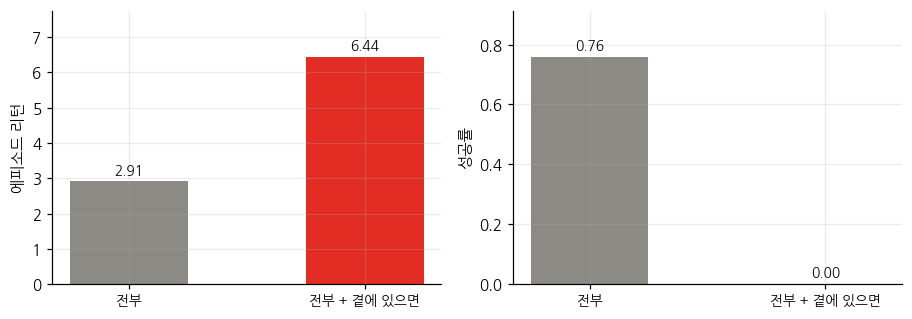

In [7]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(8.4, 3.0))
lab = ["전부", "전부 + 곁에 있으면"]
for a, vals, ttl in ((a1, [r0, rets_g[-1]], "에피소드 리턴"),
                     (a2, [s0, s_g], "성공률")):
    a.bar([0, 1], vals, color=(GREY, RED), width=.5)
    for i, v in enumerate(vals):
        a.text(i, v + max(vals) * .03, f"{v:.2f}", ha="center",
               fontsize=9)
    a.set_ylabel(ttl)
    a.set_ylim(0, max(vals) * 1.2)
    a.set_xticks([0, 1])
    a.set_xticklabels(lab, fontsize=9)
plt.tight_layout()
plt.show()

## 보상을 못 고치면 과제를 고친다

희소 보상으로 돌아간다. 실무에서는 조밀한 보상을 짤 수 없는 과제가 흔하다. 무엇이 좋은 자세인지 적을 수 없는 조작 과제가 그렇고, 성공과 실패만 정의되는 과제가 그렇다.

그럴 때 남은 손잡이가 **난이도**다. 목표를 8 cm 앞에 두면 우연한 밀침으로도 성공이 나온다. 성공이 나오면 학습할 신호가 생기고, 신호가 생기면 정책이 는다. 그 다음 목표를 조금 더 멀리 보낸다.

세 가지를 견준다. 처음부터 0.30에 두는 것, 승급만 하는 커리큘럼, 승급과 강등을 다 하는 커리큘럼이다. 보상은 셋 다 희소 보상 하나뿐이다.

In [8]:
B2 = 200_000
RUNS = (("고정 0.30", dict(gd=.30)),
        ("승급만", dict(gd=.08, curr=(.6, None, .30, .08, .02))),
        ("승급 · 강등",
         dict(gd=.08, curr=(.6, .25, .30, .08, .02))))
cur = []
t0 = time.time()
for name, kw in RUNS:
    ac, h, gds, _ = train(B2, seed=0, w=SPARSE, **kw)
    cur.append((name, ac, gds))
    print(f"{name} 끝  ({time.time()-t0:.0f}s)")

DIST = (.10, .16, .22, .30)
print()
print(pad("학습 방식", 14) + pad("도달 난이도", 14, True)
      + "".join(pad(f"{g:.2f} 에서", 12, True) for g in DIST))
for name, ac, gds in cur:
    print(pad(name, 14) + pad(f"{gds[-1]:.2f}", 14, True)
          + "".join(pad(f"{score(ac, gd=g, w=SPARSE):.2f}",
                          12, True) for g in DIST))

고정 0.30 끝  (53s)


승급만 끝  (107s)


승급 · 강등 끝  (162s)

학습 방식        도달 난이도   0.10 에서   0.16 에서   0.22 에서   0.30 에서


고정 0.30               0.30        0.00        0.00        0.00        0.00


승급만                  0.12        0.11        0.20        0.07        0.01


승급 · 강등             0.12        0.93        0.84        0.55        0.07


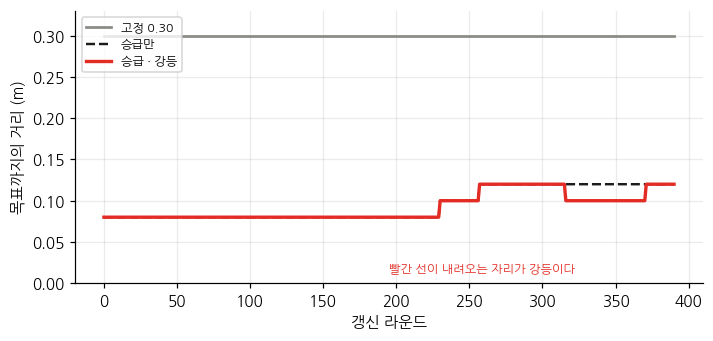

In [9]:
fig, ax = plt.subplots(figsize=(6.6, 3.2))
sty = ((GREY, "-", 1.8), (INK, "--", 1.6), (RED, "-", 2.2))
for (name, ac, gds), (c, ls, lw) in zip(cur, sty):
    ax.plot(gds, color=c, ls=ls, lw=lw, label=name)
ax.set_xlabel("갱신 라운드")
ax.set_ylabel("목표까지의 거리 (m)")
ax.set_ylim(0, .33)
ax.legend(fontsize=8, loc="upper left")
ax.text(.5, .04, "빨간 선이 내려오는 자리가 강등이다",
        transform=ax.transAxes, fontsize=8, color=RED)
plt.tight_layout()
plt.show()

## 정리

**항 하나가 학습 전부를 지탱하기도 한다.** 과제와 직접 상관없는 접근 항을 빼자 성공률이 바닥으로 갔다. 조밀한 보상에서 실제로 하는 일은 대개 「목표를 알려 주는 것」이 아니라 **「탐색을 안내하는 것」**이다.

**값을 못 하는 항은 빼는 편이 낫다.** 성공 보너스는 빼도 나빠지지 않았다. 항이 늘면 가중치가 늘고, 가중치는 서로 섞여서만 뜻을 갖는다.

**정책은 우리가 적은 문제를 푼다.** 밀대가 곁에 있는 것만으로 보상을 주자 리턴은 두 배가 되고 성공률은 0이 됐다. 증상이 조용하다는 것이 더 무섭다 — 리턴만 보고 있었다면 잘되고 있다고 읽었을 것이다.

**리턴과 과제 지표는 언제나 따로 본다.** 그리고 상태에 대해 매 스텝 주는 보상은 에피소드 길이에 비례해 쌓인다는 것을 기억한다. 차이로 주면 그 문제가 생기지 않는다.

**보상을 못 고치면 난이도를 고친다.** 희소 보상에서 고정 난이도는 끝까지 0이었고, 커리큘럼은 0에서 벗어나게 했다. 다만 조밀한 보상만큼 가지는 못했고 표본을 더 먹었다.

**커리큘럼에는 강등이 있어야 한다.** 승급만 하면 난이도가 정책을 앞질러 어느 자리에서도 여물지 못한다. 7장의 ADR에서 폭을 넓히기만 하지 않고 줄이기도 했던 것과 같은 장치다.

다음 장은 이 파이프라인이 실제로 크게 이긴 자리를 본다. 로코모션이다.